# 13 — Gaussian Naive Bayes Classification

**Course:** 23CSE301 Machine Learning — Capstone Project  
**Review:** Review 1  
**Track:** Classification — Part A  
**Dataset:** `riceClassification_sampled.csv`


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Class"

def resolve_file(filename):
    candidates = [
        Path("../data") / filename,
        Path("data") / filename,
        Path("/mnt/data") / filename,
        Path(filename)
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename}")

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)
        iqr = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * iqr
        self.upper_ = self.q3_ + self.factor * iqr
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

In [2]:
DATA_PATH = resolve_file("riceClassification_sampled.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH.resolve())
print("Shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
display(df[TARGET].value_counts().sort_index())

print("\nClass proportions:")
display(df[TARGET].value_counts(normalize=True).sort_index())

display(df.head())

Dataset: C:\Sem-5\ml\jyp_notebook\classif_review1\riceClassification_sampled.csv
Shape: (1900, 12)

Data types:


,dtype
id,int64
Area,int64
MajorAxisLength,float64
MinorAxisLength,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Perimeter,float64
Roundness,float64



Missing values:


,missing
id,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0



Duplicate rows: 0

Class distribution:


Class
0     863
1    1037
Name: count, dtype: int64


Class proportions:


Class
0    0.454211
1    0.545789
Name: proportion, dtype: float64

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,18057,9429,174.671378,69.661360,0.917032,9752,109.569045,0.644938,406.975,0.715385,2.507436,0
1,3257,5842,145.807572,51.673280,0.935096,6020,86.245379,0.641978,330.790,0.670914,2.821721,1
2,17107,8359,158.012446,67.848264,0.903121,8540,103.164962,0.666268,370.413,0.765582,2.328909,0
3,9811,6493,167.571643,50.974529,0.952610,6737,90.923838,0.796687,366.921,0.606052,3.287360,1
4,9564,5594,153.172203,47.071526,0.951609,5770,84.394917,0.496847,337.176,0.618328,3.254031,1


### A1 observation — student input
Use the actual audit output to describe the dataset size, data types, missing values, duplicates and class balance.

## 1. Cleaning & feature engineering — B1/B3

In [3]:
df = df.copy()

# `id` is only a record identifier, not a grain property.
df = df.drop(columns=["id"], errors="ignore")

print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after removal:", df.duplicated().sum())

numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]

outlier_rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rows.append({
        "Feature": col,
        "IQR Outliers": int(((df[col] < lower) | (df[col] > upper)).sum()),
        "Lower Bound": lower,
        "Upper Bound": upper
    })

display(pd.DataFrame(outlier_rows))

print("Missing values after cleaning:")
display(df.isnull().sum().to_frame("missing"))

# Geometric shape feature.
df["Compactness"] = 4 * np.pi * df["Area"] / (df["Perimeter"]**2 + 1e-8)
display(df[["Area", "Perimeter", "Compactness", TARGET]].head())

Duplicate rows before removal: 0
Duplicate rows after removal: 0


,Feature,IQR Outliers,Lower Bound,Upper Bound
0,Area,0,2192.250000,12234.250000
1,MajorAxisLength,51,124.824043,181.366070
2,MinorAxisLength,0,22.799055,98.946719
3,Eccentricity,13,0.815290,1.017077
4,ConvexArea,0,2266.750000,12530.750000
5,EquivDiameter,1,61.985845,128.950054
6,Extent,0,0.265153,0.970075
7,Perimeter,31,276.407500,431.443500
8,Roundness,2,0.469086,0.952047
9,AspectRation,0,1.058178,4.109027


Missing values after cleaning:


,missing
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0
AspectRation,0


,Area,Perimeter,Compactness,Class
0,9429,406.975,0.715385,0
1,5842,330.790,0.670914,1
2,8359,370.413,0.765582,0
3,6493,366.921,0.606052,1
4,5594,337.176,0.618328,1


### B1 justification — student input

Explain why the ID is excluded, why duplicates are removed if present, why median imputation is used for
numeric missing values, and why IQR-flagged extreme measurements should not automatically be deleted when
they may represent legitimate rice grains.

### B3 justification — student input

Explain why compactness is a meaningful shape descriptor and why it could help distinguish the rice classes.

## 2. EDA — A2/A3

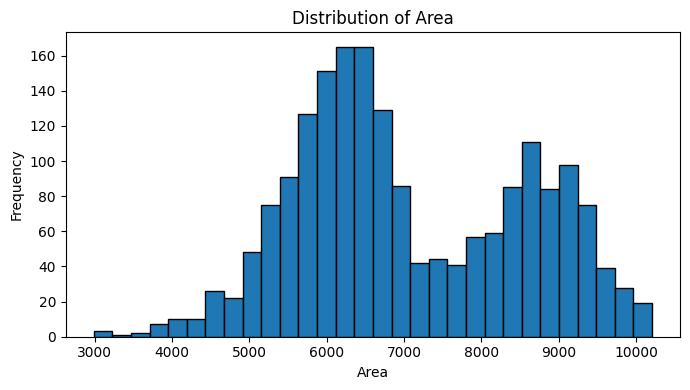

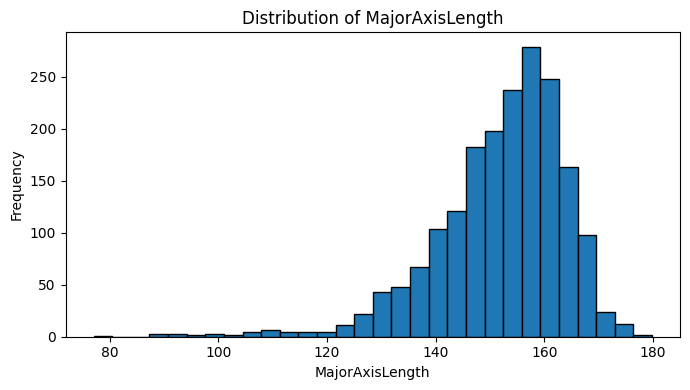

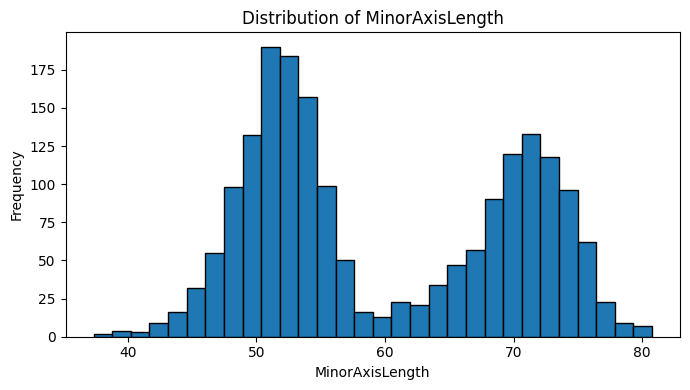

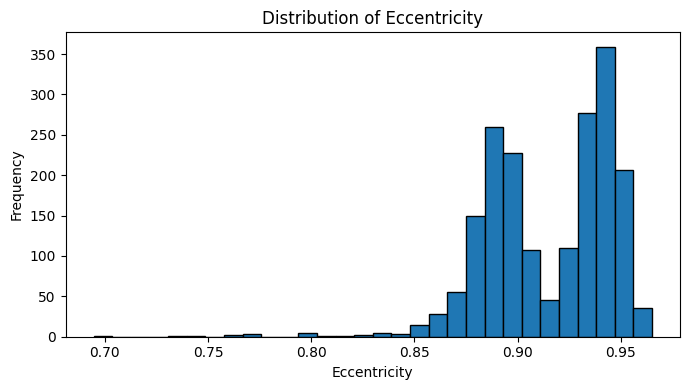

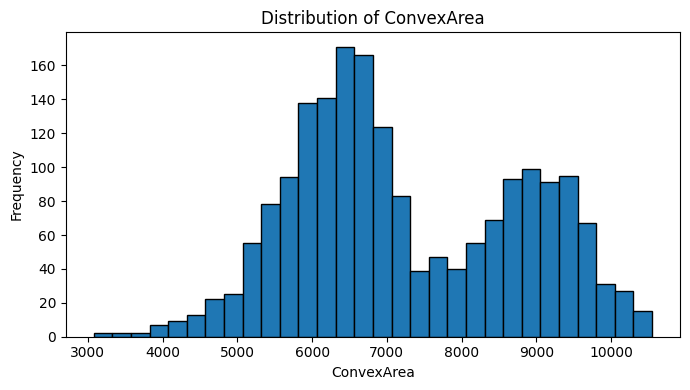

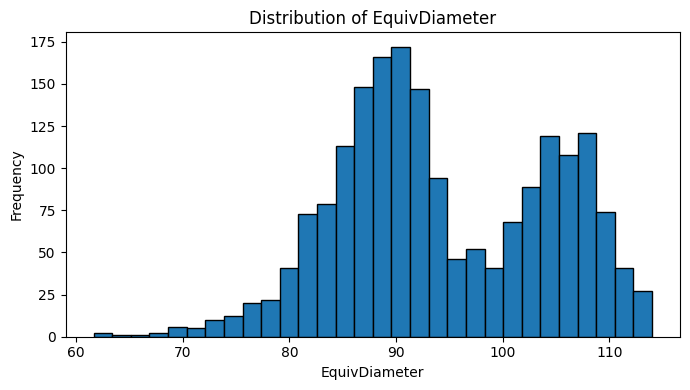

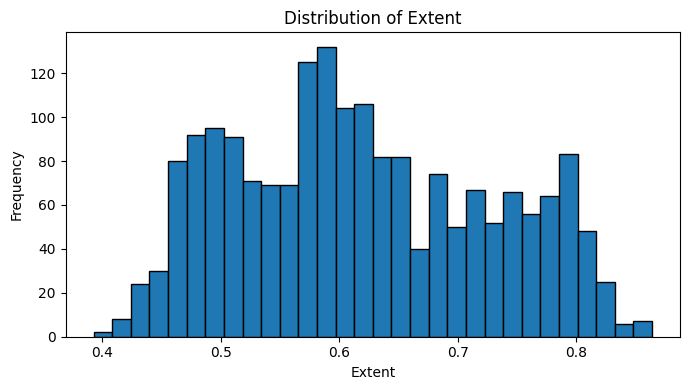

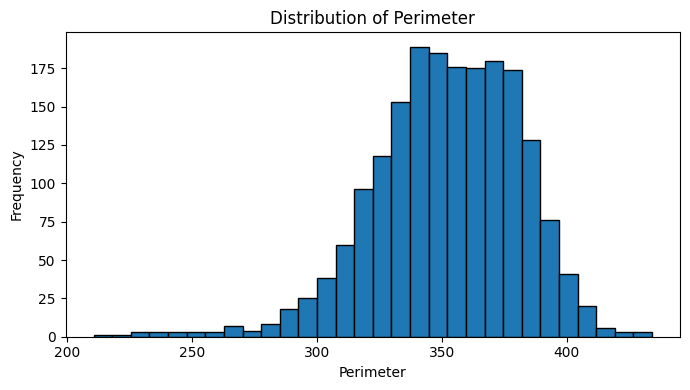

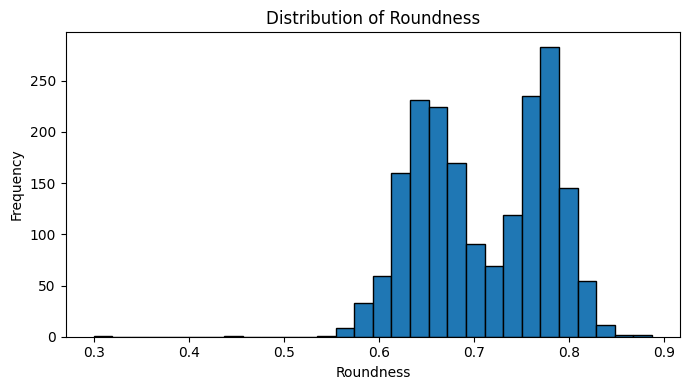

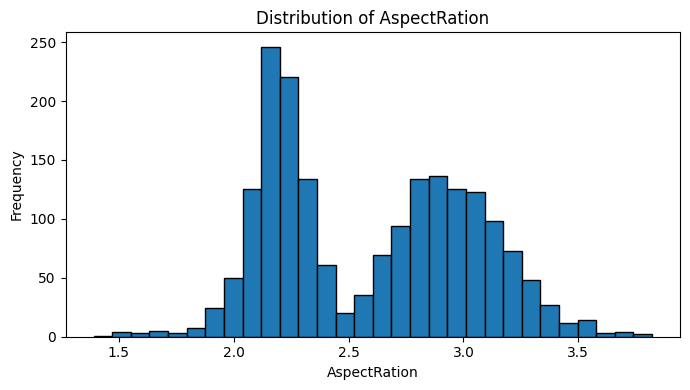

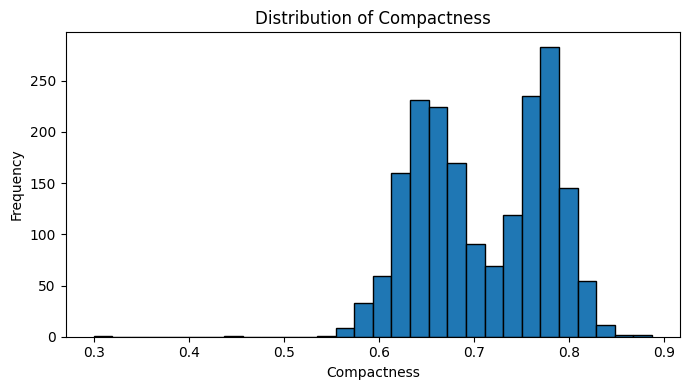

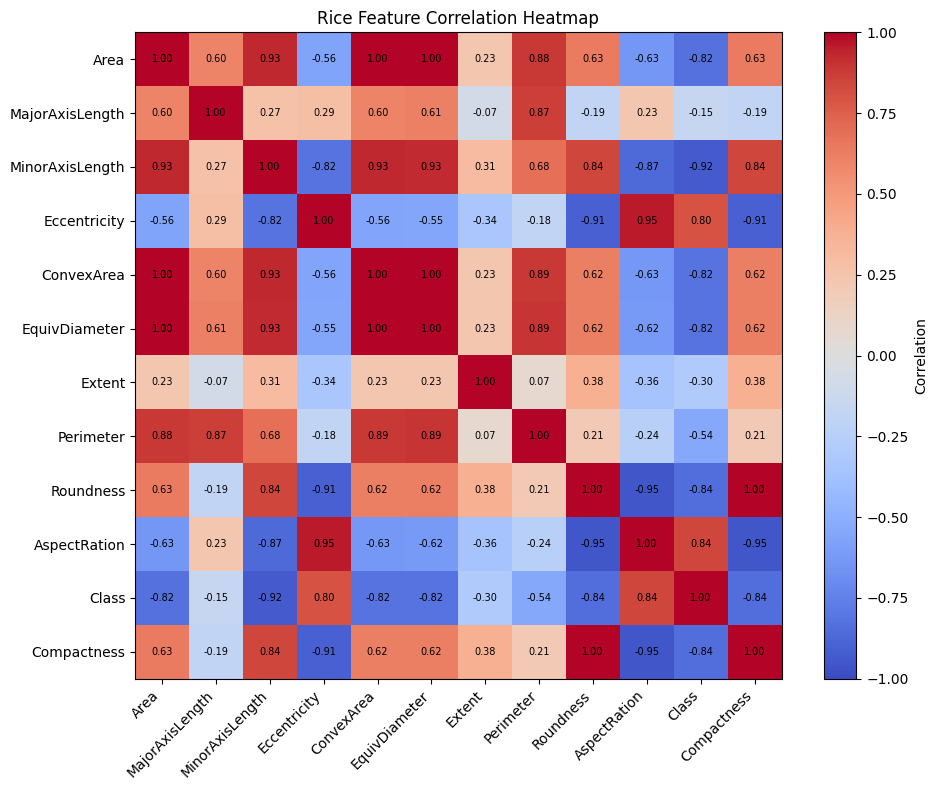

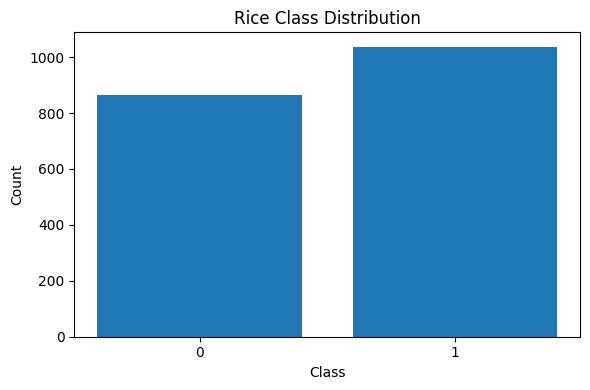

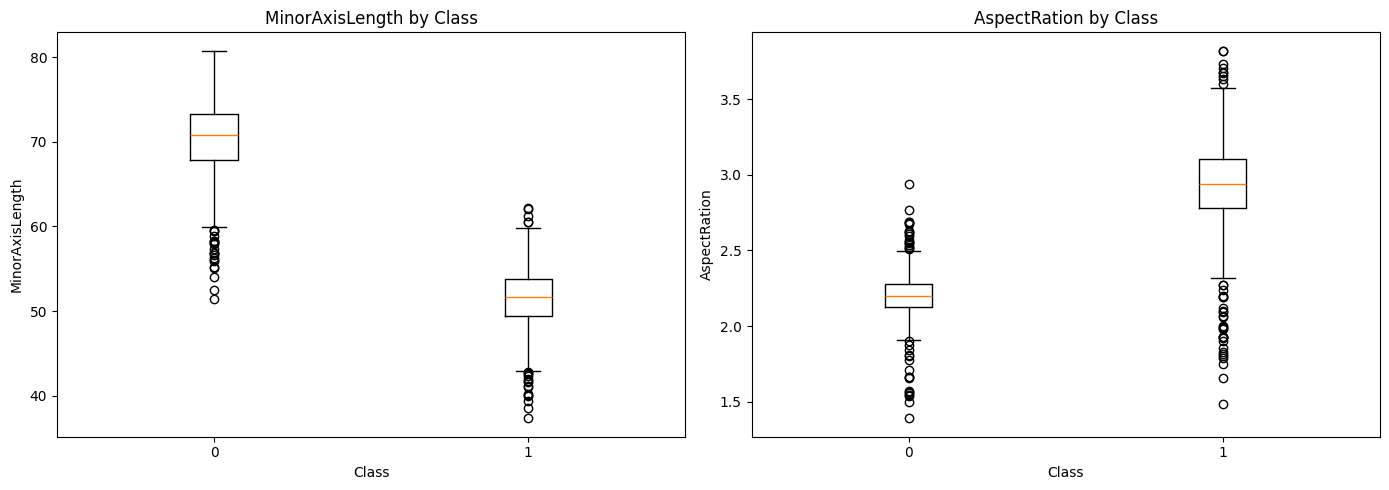

In [4]:
# Feature distributions
numeric_eda = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]

for col in numeric_eda:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Correlation heatmap
corr = df.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Rice Feature Correlation Heatmap")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

# Class distribution
counts = df[TARGET].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Rice Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Two feature-vs-target views
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = sorted(df[TARGET].unique())
for idx, cls in enumerate(classes):
    axes[0].boxplot(
        df.loc[df[TARGET] == cls, "MinorAxisLength"].dropna(),
        positions=[idx]
    )
    axes[1].boxplot(
        df.loc[df[TARGET] == cls, "AspectRation"].dropna(),
        positions=[idx]
    )

for ax, feature in zip(axes, ["MinorAxisLength", "AspectRation"]):
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels([str(c) for c in classes])
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)
    ax.set_title(f"{feature} by Class")

plt.tight_layout()
plt.show()

### A3 observation — student input

Write observations for:
1. feature distributions,
2. the correlation heatmap,
3. class balance,
4. `MinorAxisLength` by class,
5. `AspectRation` by class.

Use only findings supported by the actual plots.

## 3. Stratified train/test split & leakage-safe preprocessing — B2

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("iqr", IQRClipper()),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Train shape: (1520, 11)
Test shape: (380, 11)

Train class proportions:
Class
0    0.453947
1    0.546053
Name: proportion, dtype: float64

Test class proportions:
Class
0    0.455263
1    0.544737
Name: proportion, dtype: float64


### B2 note

The train/test split is stratified. Imputation, IQR clipping and scaling are inside the pipeline, so they
are fitted only on the training data during fitting and cross-validation.

## 4. Gaussian Naive Bayes — D1

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)
proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, average="weighted", zero_division=0)
recall = recall_score(y_test, pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
auc = roc_auc_score(y_test, proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Accuracy: 0.9842
Weighted Precision: 0.9847
Weighted Recall: 0.9842
Weighted F1: 0.9842
ROC-AUC: 0.9956


### Algorithm interpretation — student input
Discuss the conditional-independence assumption and relate it to the correlations found during EDA.

## 5. Confusion matrix — D2

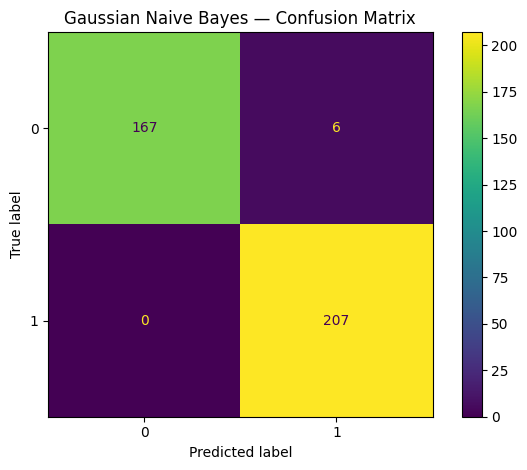

Confusion matrix:
 [[167   6]
 [  0 207]]


In [7]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Gaussian Naive Bayes — Confusion Matrix")
plt.tight_layout()
plt.show()

print("Confusion matrix:\n", cm)

### D2 observation — student input
Identify the false positives and false negatives and relate the pattern to Accuracy and weighted F1.

## 6. 5-fold stratified cross-validation

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    pipeline, X, y, cv=cv, scoring="accuracy"
)

print("5-fold CV accuracy:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std CV accuracy: {cv_scores.std():.4f}")

5-fold CV accuracy: [0.9842 0.9868 0.9921 0.9895 0.9789]
Mean CV accuracy: 0.9863
Std CV accuracy: 0.0045


### CV observation — student input
Compare mean CV accuracy and held-out test accuracy.

## 7. Save model and result for the collective Part-A comparison

In [9]:
root = Path("..") if Path("../data").exists() else Path(".")
(root / "results").mkdir(parents=True, exist_ok=True)
(root / "models").mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline, root / "models" / "gaussian_nb_classification_baseline.joblib")

result = pd.DataFrame([{
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1_weighted": f1,
    "ROC_AUC": auc,
    "CV_Accuracy_Mean": cv_scores.mean(),
    "CV_Accuracy_Std": cv_scores.std()
}])

result.to_csv(root / "results" / "classification_gaussian_nb_results.csv", index=False)
display(result)

,Model,Accuracy,Precision,Recall,F1_weighted,ROC_AUC,CV_Accuracy_Mean,CV_Accuracy_Std
0,Gaussian Naive Bayes,0.984211,0.984655,0.984211,0.984184,0.995616,0.986316,0.004528
